In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [26]:
df = pd.read_csv('diabetic_data.csv', na_values='?')
df

C:\Users\laigu\AppData\Local\Temp\ipykernel_15984\215799673.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('diabetic_data.csv', na_values='?')


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [28]:
# Valores de nulos por columna
nulos_pct = df.isnull().sum() / len(df) * 100
print("Columnas con nulos (%):")
print(nulos_pct.sort_values(ascending=False))

Columnas con nulos (%):
weight                      96.858479
max_glu_serum               94.746772
A1Cresult                   83.277322
medical_specialty           49.082208
payer_code                  39.557416
race                         2.233555
diag_3                       1.398306
diag_2                       0.351787
diag_1                       0.020636
patient_nbr                  0.000000
time_in_hospital             0.000000
admission_source_id          0.000000
num_lab_procedures           0.000000
encounter_id                 0.000000
admission_type_id            0.000000
discharge_disposition_id     0.000000
gender                       0.000000
age                          0.000000
number_inpatient             0.000000
number_emergency             0.000000
number_outpatient            0.000000
num_medications              0.000000
num_procedures               0.000000
number_diagnoses             0.000000
metformin                    0.000000
repaglinide               

In [29]:
# eliminacion de las columnas que tienen mas de 39% de datos nulos
df_clean= df.drop(columns=['weight', 'payer_code', 'medical_specialty','max_glu_serum','A1Cresult'])

In [30]:
#para el resto de las columnas se cmpleta los valores nulos con la moda.
df_clean['race'] = df_clean['race'].fillna(df_clean['race'].mode()[0])
df_clean['diag_1'] = df_clean['diag_1'].fillna(df_clean['diag_1'].mode()[0])
df_clean['diag_2'] = df_clean['diag_2'].fillna(df_clean['diag_2'].mode()[0])
df_clean['diag_3'] = df_clean['diag_3'].fillna(df_clean['diag_3'].mode()[0])

In [31]:
nulos_pct = df_clean.isnull().sum() / len(df_clean) * 100
print("Columnas con nulos (%):")
print(nulos_pct.sort_values(ascending=False))

Columnas con nulos (%):
encounter_id                0.0
patient_nbr                 0.0
race                        0.0
gender                      0.0
age                         0.0
admission_type_id           0.0
discharge_disposition_id    0.0
admission_source_id         0.0
time_in_hospital            0.0
num_lab_procedures          0.0
num_procedures              0.0
num_medications             0.0
number_outpatient           0.0
number_emergency            0.0
number_inpatient            0.0
diag_1                      0.0
diag_2                      0.0
diag_3                      0.0
number_diagnoses            0.0
metformin                   0.0
repaglinide                 0.0
nateglinide                 0.0
chlorpropamide              0.0
glimepiride                 0.0
acetohexamide               0.0
glipizide                   0.0
glyburide                   0.0
tolbutamide                 0.0
pioglitazone                0.0
rosiglitazone               0.0
acarbose        

C:\Users\laigu\AppData\Local\Temp\ipykernel_15984\3136383308.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=conteos, palette='Set2')


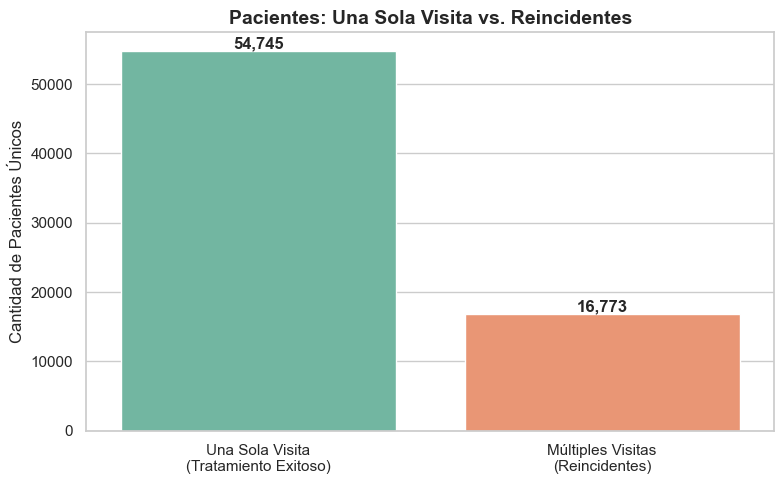

In [32]:

# Identificion grupos de pacientes
visitas_por_paciente = df['patient_nbr'].value_counts()
pacientes_una_visita = visitas_por_paciente[visitas_por_paciente == 1].index
pacientes_multiples = visitas_por_paciente[visitas_por_paciente > 1].index

# Códigos de alta relacionados con fallecimiento.
codigos_fallecidos = [11, 13, 14, 19, 20, 21]
pacientes_fallecidos = df[df['discharge_disposition_id'].isin(codigos_fallecidos)]['patient_nbr'].unique()

# DataFrames por grupo se toma la primera/única visita de cada uno para no duplicar datos de medicación
df_una_visita = df[df['patient_nbr'].isin(pacientes_una_visita)]
df_multiples = df.sort_values('encounter_id').drop_duplicates(subset=['patient_nbr'], keep='first')
df_multiples = df_multiples[df_multiples['patient_nbr'].isin(pacientes_multiples)]
df_fallecidos = df.sort_values('encounter_id').drop_duplicates(subset=['patient_nbr'], keep='last')
df_fallecidos = df_fallecidos[df_fallecidos['patient_nbr'].isin(pacientes_fallecidos)]

# 2. Gráfico: Cantidad de pacientes por grupo de reincidencia
plt.figure(figsize=(8, 5))
categorias = ['Una Sola Visita\n(Tratamiento Exitoso)', 'Múltiples Visitas\n(Reincidentes)']
conteos = [len(pacientes_una_visita), len(pacientes_multiples)]

sns.barplot(x=categorias, y=conteos, palette='Set2')
plt.title('Pacientes: Una Sola Visita vs. Reincidentes', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Pacientes Únicos')

for i, v in enumerate(conteos):
    plt.text(i, v + 500, f"{v:,}", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
import os
os.makedirs('../graficos', exist_ok=True)
plt.savefig('../graficos/visitas_pacientes.png', dpi=300)
plt.show()



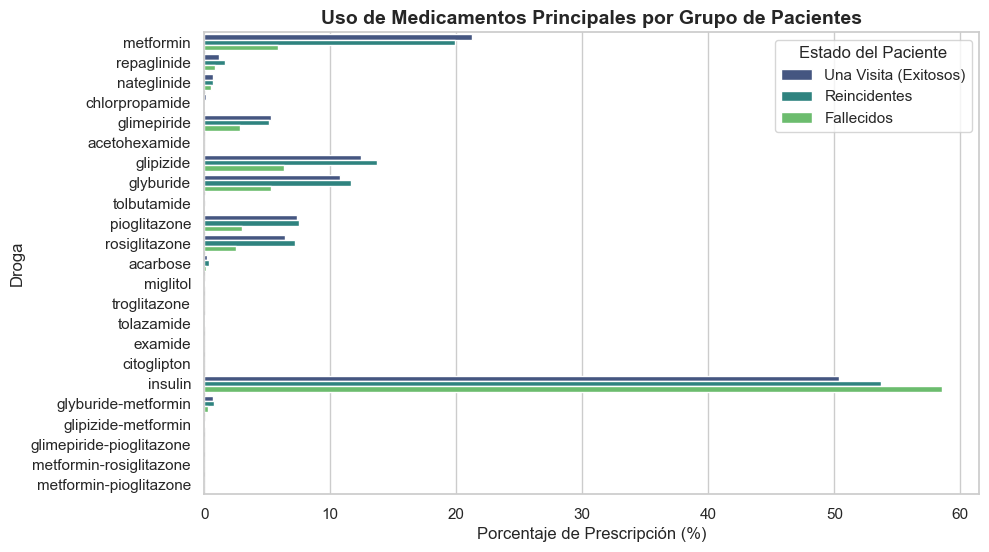

In [33]:
# valores estándar las columnas de dosis médicas.
valores_dosis = {'No', 'Steady', 'Up', 'Down'}

# Filtros para medicamentos.
medicamentos = [
    col for col in df_una_visita.columns 
    if set(df_una_visita[col].dropna().unique()).issubset(valores_dosis)
]


# Porcentajes de medicamentos en De grupos de pacientes
pct_una_visita = []
pct_multiples = []
pct_fallecidos = []

for med in medicamentos:
    # Porcentaje en "Una Visita"
    uso_una = (df_una_visita[med] != 'No').sum() / len(df_una_visita) * 100
    pct_una_visita.append(uso_una)
    
    # Porcentaje en "Múltiples Visitas"
    uso_multiples = (df_multiples[med] != 'No').sum() / len(df_multiples) * 100
    pct_multiples.append(uso_multiples)
    
    # Porcentaje en "Fallecidos"
    uso_fallecidos = (df_fallecidos[med] != 'No').sum() / len(df_fallecidos) * 100
    pct_fallecidos.append(uso_fallecidos)

# Grafico
df_resumen = pd.DataFrame({
    'Medicamento': medicamentos,
    'Una Visita (Exitosos)': pct_una_visita,
    'Reincidentes': pct_multiples,
    'Fallecidos': pct_fallecidos
})

df_plot = df_resumen.melt(id_vars='Medicamento', var_name='Grupo de Paciente', value_name='Porcentaje (%)')


plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Porcentaje (%)', y='Medicamento', hue='Grupo de Paciente', palette='viridis')

plt.title('Uso de Medicamentos Principales por Grupo de Pacientes', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje de Prescripción (%)')
plt.ylabel('Droga')
plt.legend(title='Estado del Paciente')


os.makedirs('../graficos', exist_ok=True)
plt.savefig('../graficos/medicamentos_comparativa.png', dpi=300, bbox_inches='tight')

plt.show()



In [ ]:
# Porcentaje total de medicamentos adminitrados a los pacientes ( mayor al 5% )

def obtener_medicamentos_top(df_grupo, nombre_grupo):
    print(f"\n--- Top Medicamentos Recetados: {nombre_grupo} ---")
    # Pacientes a los que se les administro medicamento para diabetes
    medicados_total = (df_grupo['diabetesMed'] == 'Yes').sum()
    print(f"Pacientes que recibieron medicación para diabetes: {medicados_total} ({(medicados_total/len(df_grupo))*100:.1f}%)")
    
    # FILTRO POR MEDICAMENTO
    for med in medicamentos:
       
        tomaron = (df_grupo[med] != 'No').sum()
        porcentaje = (tomaron / len(df_grupo)) * 100
        if porcentaje > 5: 
            print(f"- {med.capitalize()}: {porcentaje:.1f}%")

obtener_medicamentos_top(df_una_visita, "Una Sola Visita (Exitosos)")
obtener_medicamentos_top(df_multiples, "Reincidentes")
obtener_medicamentos_top(df_fallecidos, "Fallecidos / Cuidados Paliativos")


--- Top Medicamentos Recetados: Una Sola Visita (Exitosos) ---
Pacientes que recibieron medicación para diabetes: 41015 (74.9%)
- Metformin: 21.3%
- Glimepiride: 5.3%
- Glipizide: 12.4%
- Glyburide: 10.8%
- Pioglitazone: 7.4%
- Rosiglitazone: 6.4%
- Insulin: 50.4%

--- Top Medicamentos Recetados: Reincidentes ---
Pacientes que recibieron medicación para diabetes: 13304 (79.3%)
- Metformin: 19.9%
- Glimepiride: 5.2%
- Glipizide: 13.7%
- Glyburide: 11.7%
- Pioglitazone: 7.5%
- Rosiglitazone: 7.2%
- Insulin: 53.7%

--- Top Medicamentos Recetados: Fallecidos / Cuidados Paliativos ---
Pacientes que recibieron medicación para diabetes: 1627 (67.8%)
- Metformin: 5.9%
- Glipizide: 6.3%
- Glyburide: 5.3%
- Insulin: 58.6%


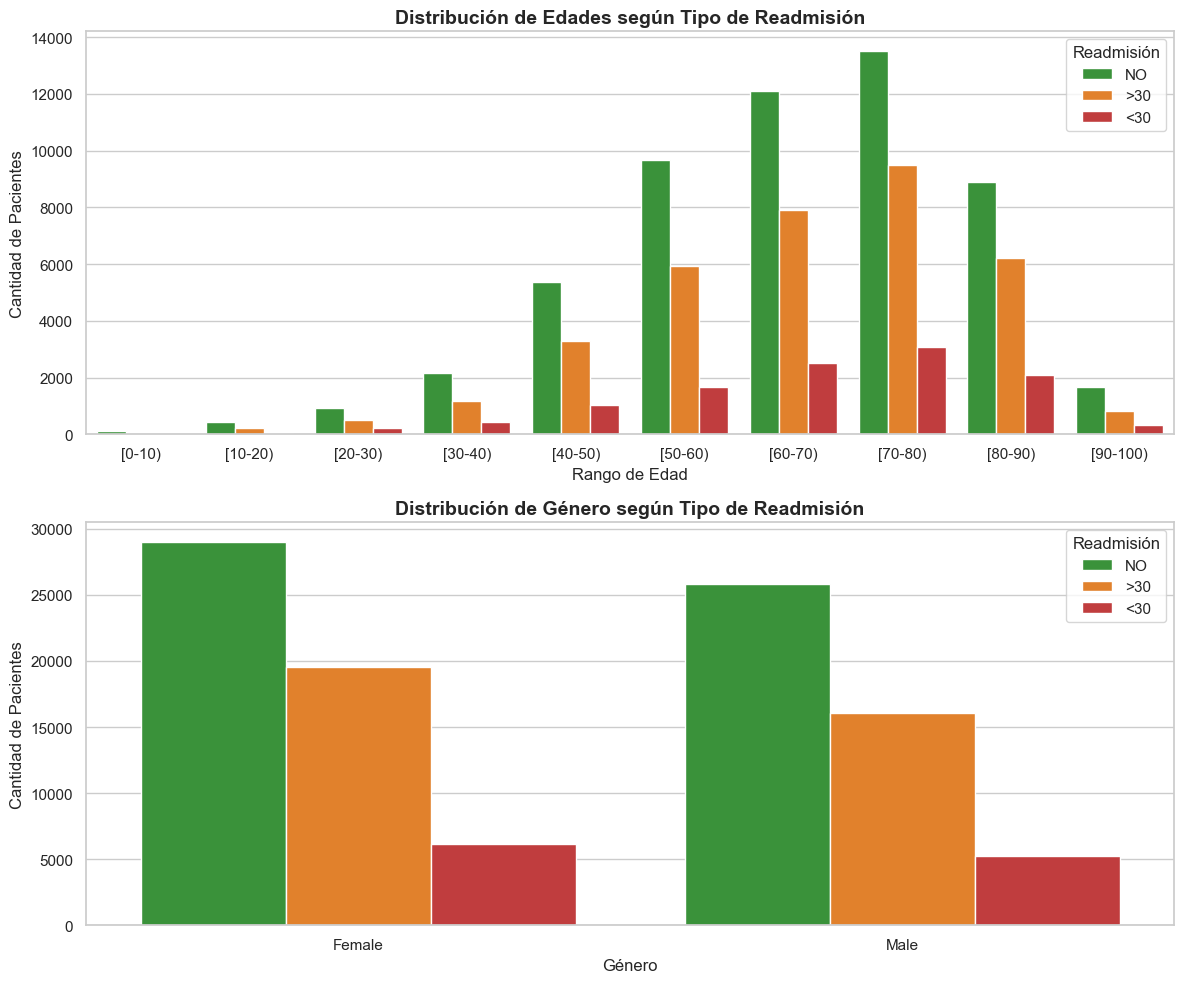

C:\Users\laigu\AppData\Local\Temp\ipykernel_15984\2621338668.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='readmitted', y='time_in_hospital', order=orden_readmision, palette=colores_readmision, ax=axes[0])
C:\Users\laigu\AppData\Local\Temp\ipykernel_15984\2621338668.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='readmitted', y='num_medications', order=orden_readmision, palette=colores_readmision, ax=axes[1])


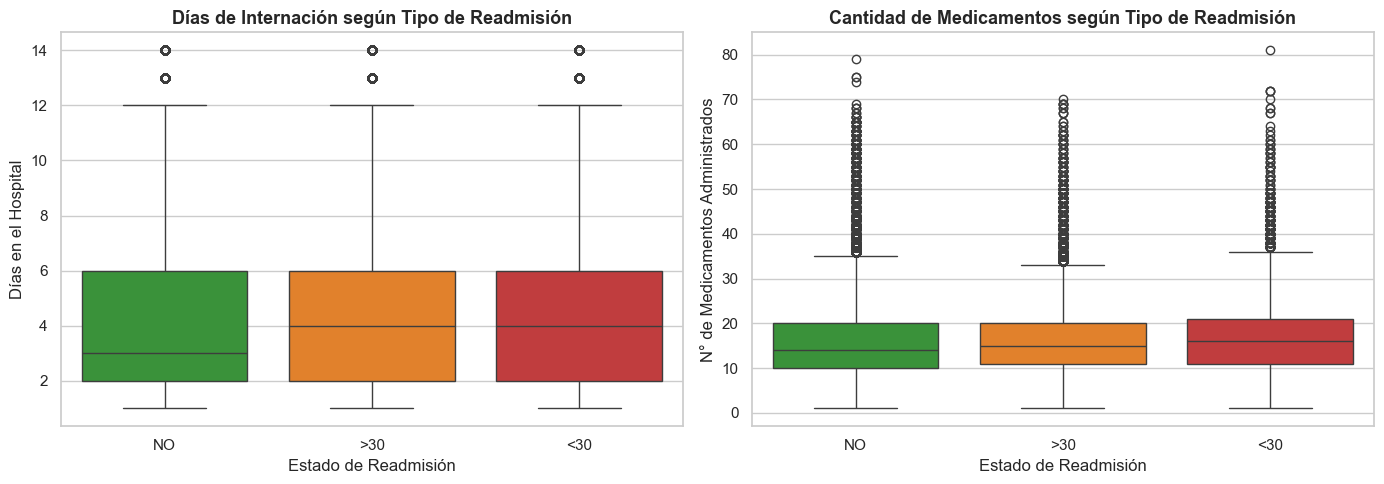

C:\Users\laigu\AppData\Local\Temp\ipykernel_15984\2621338668.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Ningún cambio (No)', 'Hubo cambio (Yes)'])


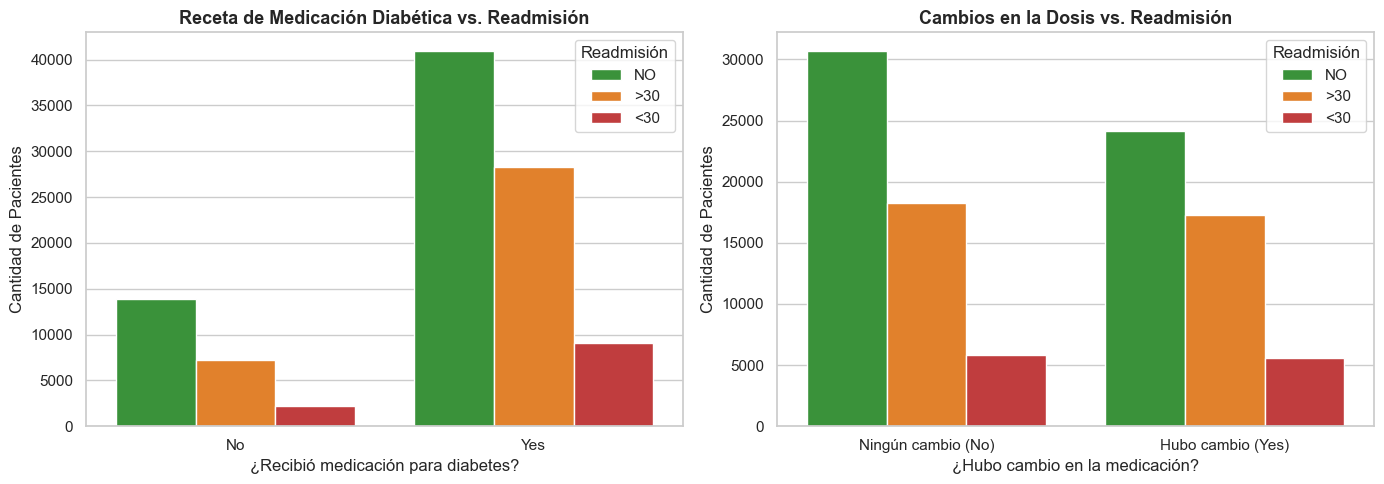

In [ ]:

os.makedirs('../graficos', exist_ok=True)
sns.set_theme(style="whitegrid")

orden_readmision = ['NO', '>30', '<30']
colores_readmision = {'NO': '#2ca02c', '>30': '#ff7f0e', '<30': '#d62728'} # Verde, Naranja, Rojo

# ==========================================
# 1. DEMOGRAFÍA (Edad y Género) vs. TIPO DE READMISIÓN
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico A: Edad
orden_edades = sorted(df_clean['age'].unique())
sns.countplot(data=df_clean, x='age', hue='readmitted', order=orden_edades, hue_order=orden_readmision, palette=colores_readmision, ax=axes[0])
axes[0].set_title('Distribución de Edades según Tipo de Readmisión', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rango de Edad')
axes[0].set_ylabel('Cantidad de Pacientes')
axes[0].legend(title='Readmisión')

# Gráfico B: Género
df_gender = df_clean[df_clean['gender'] != 'Unknown/Invalid']
sns.countplot(data=df_gender, x='gender', hue='readmitted', hue_order=orden_readmision, palette=colores_readmision, ax=axes[1])
axes[1].set_title('Distribución de Género según Tipo de Readmisión', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Cantidad de Pacientes')
axes[1].legend(title='Readmisión')

plt.tight_layout()
plt.savefig('../graficos/eda_comparativo_demografia.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 2. INTENSIDAD DEL TRATAMIENTO vs. TIPO DE READMISIÓN
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Días en el hospital
sns.boxplot(data=df_clean, x='readmitted', y='time_in_hospital', order=orden_readmision, palette=colores_readmision, ax=axes[0])
axes[0].set_title('Días de Internación según Tipo de Readmisión', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Estado de Readmisión')
axes[0].set_ylabel('Días en el Hospital')

# Gráfico B: Cantidad de medicamentos
sns.boxplot(data=df_clean, x='readmitted', y='num_medications', order=orden_readmision, palette=colores_readmision, ax=axes[1])
axes[1].set_title('Cantidad de Medicamentos según Tipo de Readmisión', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Estado de Readmisión')
axes[1].set_ylabel('N° de Medicamentos Administrados')

plt.tight_layout()
plt.savefig('../graficos/eda_comparativo_intensidad.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3. MANEJO DE LA DIABETES vs. TIPO DE READMISIÓN
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Medicación para Diabetes
sns.countplot(data=df_clean, x='diabetesMed', hue='readmitted', hue_order=orden_readmision, palette=colores_readmision, ax=axes[0])
axes[0].set_title('Receta de Medicación Diabética vs. Readmisión', fontsize=13, fontweight='bold')
axes[0].set_xlabel('¿Recibió medicación para diabetes?')
axes[0].set_ylabel('Cantidad de Pacientes')
axes[0].legend(title='Readmisión')

# Gráfico B: Cambio de Dosis
sns.countplot(data=df_clean, x='change', hue='readmitted', hue_order=orden_readmision, palette=colores_readmision, ax=axes[1])
axes[1].set_title('Cambios en la Dosis vs. Readmisión', fontsize=13, fontweight='bold')
axes[1].set_xlabel('¿Hubo cambio en la medicación?')
axes[1].set_xticklabels(['Ningún cambio (No)', 'Hubo cambio (Yes)'])
axes[1].set_ylabel('Cantidad de Pacientes')
axes[1].legend(title='Readmisión')

plt.tight_layout()
plt.savefig('../graficos/eda_comparativo_medicacion.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
print("============== REPORTE DE DATOS EDA ==============\n")

# 1. DEMOGRAFÍA (Género)
print("--- 1. GÉNERO VS READMISIÓN ---")
df_gender = df_clean[df_clean['gender'] != 'Unknown/Invalid']
genero_ct = pd.crosstab(df_gender['gender'], df_gender['readmitted'], margins=True, margins_name="Total")
print(genero_ct)

# 2. DEMOGRAFÍA (Edad)
print("\n--- 2. EDAD VS READMISIÓN (Top 3 rangos con más reingresos <30) ---")
edad_ct = pd.crosstab(df_clean['age'], df_clean['readmitted'])
# Ordenamos para ver cuáles son las edades más críticas
print(edad_ct.sort_values(by='<30', ascending=False)[['NO', '>30', '<30']])

# 3. INTENSIDAD DEL TRATAMIENTO (Usamos la Mediana porque no se afecta por valores atípicos)
print("\n--- 3. INTENSIDAD DEL TRATAMIENTO (Valores Medios / Mediana) ---")
intensidad = df_clean.groupby('readmitted')[['time_in_hospital', 'num_medications']].median()
print(intensidad)

# 4. MANEJO DE LA DIABETES (Medicación)
print("\n--- 4. MEDICACIÓN PARA DIABETES VS READMISIÓN ---")
med_ct = pd.crosstab(df_clean['diabetesMed'], df_clean['readmitted'], normalize='index') * 100
print("Porcentaje de readmisión según si recibió medicación (Yes/No):")
print(med_ct.round(2).astype(str) + '%')

# 5. MANEJO DE LA DIABETES (Cambios de Dosis)
print("\n--- 5. CAMBIO DE DOSIS VS READMISIÓN ---")
cambio_ct = pd.crosstab(df_clean['change'], df_clean['readmitted'], normalize='index') * 100
print("Porcentaje de readmisión según si hubo cambio en la dosis (Yes/No):")
print(cambio_ct.round(2).astype(str) + '%')

============== REPORTE DE DATOS EDA ==============

--- 1. GÉNERO VS READMISIÓN ---
readmitted    <30    >30     NO   Total
gender                                 
Female       6152  19518  29038   54708
Male         5205  16027  25823   47055
Total       11357  35545  54861  101763

--- 2. EDAD VS READMISIÓN (Top 3 rangos con más reingresos <30) ---
readmitted     NO   >30   <30
age                          
[70-80)     13524  9475  3069
[60-70)     12084  7897  2502
[80-90)      8896  6223  2078
[50-60)      9671  5917  1668
[40-50)      5380  3278  1027
[30-40)      2164  1187   424
[90-100)     1675   808   310
[20-30)       911   510   236
[10-20)       427   224    40
[0-10)        132    26     3

--- 3. INTENSIDAD DEL TRATAMIENTO (Valores Medios / Mediana) ---
            time_in_hospital  num_medications
readmitted                                   
<30                      4.0             16.0
>30                      4.0             15.0
NO                       3.0         

In [40]:
print("============== REPORTE DE DATOS EDA ==============\n")

# 1. DEMOGRAFÍA (Género)
print("--- 1. GÉNERO VS READMISIÓN ---")
df_gender = df_clean[df_clean['gender'] != 'Unknown/Invalid']
# normalize='columns' calcula sobre el 100% de cada tipo de readmisión
genero_ct = pd.crosstab(df_gender['gender'], df_gender['readmitted'], normalize='columns') * 100
print("Distribución de género por tipo de readmisión (%):")
print(genero_ct.round(2).astype(str) + '%')

# 2. DEMOGRAFÍA (Edad)
print("\n--- 2. EDAD VS READMISIÓN ---")
edad_ct = pd.crosstab(df_clean['age'], df_clean['readmitted'], normalize='columns') * 100
print("Top 3 rangos de edad con mayor proporción de reingresos tempranos (<30):")
print(edad_ct.sort_values(by='<30', ascending=False)[['NO', '>30', '<30']].head(3).round(2).astype(str) + '%')


# 3. MANEJO DE LA DIABETES (Medicación)
print("\n--- 4. MEDICACIÓN PARA DIABETES VS READMISIÓN ---")
# normalize='index' calcula sobre el 100% de los que recibieron (o no) medicación
med_ct = pd.crosstab(df_clean['diabetesMed'], df_clean['readmitted'], normalize='index') * 100
print("Riesgo de readmisión según si recibió medicación (%):")
print(med_ct.round(2).astype(str) + '%')

# 4. MANEJO DE LA DIABETES (Cambios de Dosis)
print("\n--- 5. CAMBIO DE DOSIS VS READMISIÓN ---")
cambio_ct = pd.crosstab(df_clean['change'], df_clean['readmitted'], normalize='index') * 100
print("Riesgo de readmisión según si hubo cambio en la dosis (%):")
print(cambio_ct.round(2).astype(str) + '%')

============== REPORTE DE DATOS EDA ==============

--- 1. GÉNERO VS READMISIÓN ---
Distribución de género por tipo de readmisión (%):
readmitted     <30     >30      NO
gender                            
Female      54.17%  54.91%  52.93%
Male        45.83%  45.09%  47.07%

--- 2. EDAD VS READMISIÓN ---
Top 3 rangos de edad con mayor proporción de reingresos tempranos (<30):
readmitted      NO     >30     <30
age                               
[70-80)     24.65%  26.66%  27.02%
[60-70)     22.03%  22.22%  22.03%
[80-90)     16.21%  17.51%   18.3%

--- 4. MEDICACIÓN PARA DIABETES VS READMISIÓN ---
Riesgo de readmisión según si recibió medicación (%):
readmitted      <30     >30      NO
diabetesMed                        
No             9.6%  30.88%  59.52%
Yes          11.63%  36.14%  52.24%

--- 5. CAMBIO DE DOSIS VS READMISIÓN ---
Riesgo de readmisión según si hubo cambio en la dosis (%):
readmitted     <30     >30      NO
change                            
Ch          11.82%  36.74%

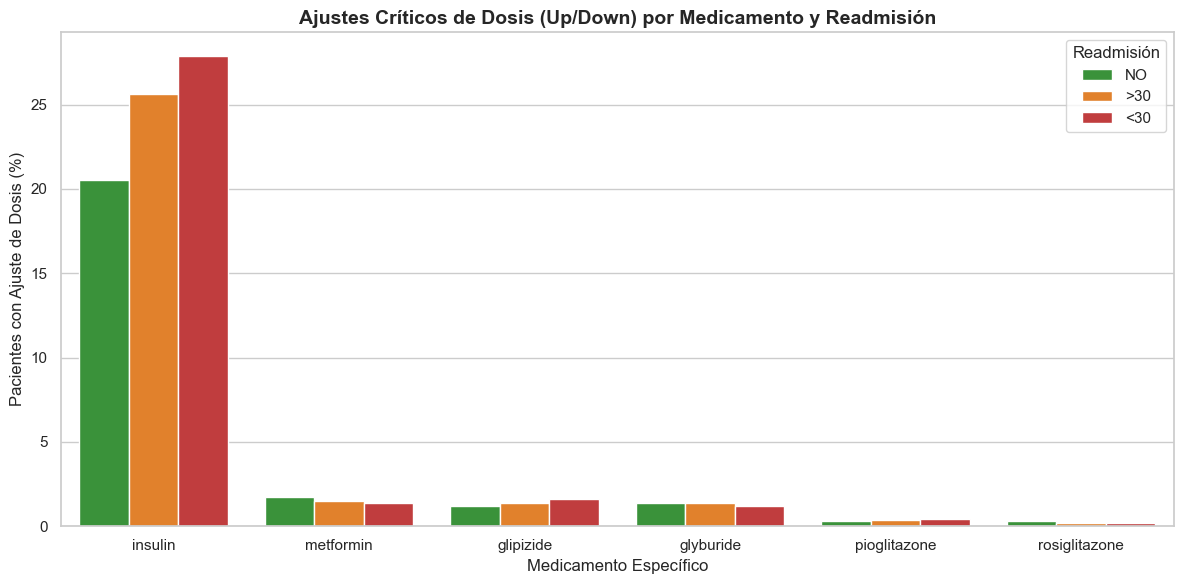

=== % DE PACIENTES CON AJUSTE DE DOSIS (UP / DOWN) ===
           insulin metformin glipizide glyburide pioglitazone rosiglitazone
readmitted                                                                 
NO          20.51%     1.73%     1.18%     1.35%        0.31%          0.3%
>30         25.64%     1.51%      1.4%      1.4%        0.39%         0.21%
<30         27.89%     1.38%     1.62%     1.21%        0.41%         0.21%


In [38]:
sns.set_theme(style="whitegrid")

# 1. Definimos las drogas más comunes para no saturar el gráfico
top_meds = ['insulin', 'metformin', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone']

# 2. Creamos un DataFrame temporal para calcular los porcentajes de ajuste
df_cambios = pd.DataFrame()
df_cambios['readmitted'] = df_clean['readmitted']

for med in top_meds:
    # Consideramos un "ajuste" si a ese medicamento específico se le subió (Up) o bajó (Down) la dosis
    df_cambios[med] = df_clean[med].isin(['Up', 'Down']).astype(int) * 100

# 3. Calculamos el % de pacientes que sufrieron cambios en cada droga, por grupo de readmisión
df_resumen = df_cambios.groupby('readmitted')[top_meds].mean().reset_index()

# 4. Transformamos los datos al formato largo para Seaborn (Melt)
df_plot = df_resumen.melt(id_vars='readmitted', var_name='Medicamento', value_name='Porcentaje con Ajuste (%)')

# 5. Generamos el gráfico comparativo
plt.figure(figsize=(12, 6))
orden_readmision = ['NO', '>30', '<30']
colores_readmision = {'NO': '#2ca02c', '>30': '#ff7f0e', '<30': '#d62728'} # Verde, Naranja, Rojo

sns.barplot(data=df_plot, x='Medicamento', y='Porcentaje con Ajuste (%)', 
            hue='readmitted', hue_order=orden_readmision, palette=colores_readmision)

plt.title('Ajustes Críticos de Dosis (Up/Down) por Medicamento y Readmisión', fontsize=14, fontweight='bold')
plt.xlabel('Medicamento Específico')
plt.ylabel('Pacientes con Ajuste de Dosis (%)')
plt.legend(title='Readmisión')

plt.tight_layout()
plt.savefig('../graficos/eda_ajustes_dosis_especificas.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Imprimir el reporte para la documentación
print("=== % DE PACIENTES CON AJUSTE DE DOSIS (UP / DOWN) ===")
# Reordenamos el índice para que coincida con la lógica clínica
df_resumen_ordenado = df_resumen.set_index('readmitted').reindex(['NO', '>30', '<30'])
print(df_resumen_ordenado.round(2).astype(str) + '%')